In [1]:
%matplotlib inline
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import brainmass
import brainstate
import braintools
import brainunit as u
from brainstate.nn import Param
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Creating a Coupling

A **coupling** turns the per-region states of a network into the input current
each region receives from the others. `brainmass` ships diffusive, additive, and
several nonlinear couplings (`DiffusiveCoupling`, `SigmoidalCoupling`, ...). This
guide shows how to implement a *new* one against the same stable contract, so it
drops into a network exactly like the built-ins.

If you only want to *use* the existing couplings through `Network(coupling=...)`,
see {doc}`/howto/custom_coupling`. This guide is about the implementation contract.

Every coupling in `coupling.py` follows one pattern:

1. a **pure kernel function** doing the array math, and
2. a thin **`Module`** that holds the `Param`s and the prefetch reads, and calls
   the kernel from `update`.

We will reproduce that pattern for a new *power-law diffusive* coupling.

## The prefetch / delay contract

A coupling never reads another module's state directly. It reads a **prefetch** --
a zero-argument callable a node hands out that yields a (optionally delayed)
snapshot of one of its states. There are two reads, and their shapes are the whole
contract:

- **Source** (`prefetch_delay`): every target reads *every* source, so the source
  read is shaped `(..., N, N)` -- `x[i, j]` is source `j` as seen by target `i`,
  already delayed by the conduction delay `tau_ij = distance_ij / speed`.
- **Target** (`prefetch`): each target reads its *own* current state, shaped
  `(..., N)`.

A diffusive coupling needs both (it forms `x_j - y_i`); an additive one needs only
the source. The node builds these reads; the coupling just consumes them:

```python
src = node.prefetch_delay(coupled_var, (delay_matrix, idx), init=delay_init)  # (.., N, N)
tgt = node.prefetch(coupled_var)                                              # (.., N)
```

`init_maybe_prefetch` (called from the coupling's `init_state`) sizes the delay
buffer from `delay / dt`, so a global `dt` must be live in the environment before a
delay-coupled network is constructed.

## Step 1 -- the kernel function

The kernel does the math on plain arrays (or callables that return them). Mirror
`brainmass.diffusive_coupling`: accept the source/target reads, the connection
matrix, and the strength `k`; return the `(..., N)` current. Strip units with
`brainunit.get_magnitude` before any transcendental (here `abs` / `sign` / a
fractional power), then let `k` carry the output's units back.

In [2]:
def powerlaw_coupling(delayed_x, y, conn, k, p=1.0):
    """Power-law diffusive kernel: k * sum_j conn_ij * sign(d) * |d|**p, d = x_ij - y_i.

    A generalisation of diffusive coupling: p=1 recovers it; p<1 emphasises small
    differences, p>1 emphasises large ones.
    """
    # target read -> (..., N), expand to (..., N, 1) to broadcast against sources
    y_val = y() if callable(y) else y
    y_exp = u.math.expand_dims(y_val, axis=-1)
    # source read -> (..., N, N)
    x_mat = delayed_x() if callable(delayed_x) else delayed_x
    # difference, made dimensionless for the nonlinearity
    diff = u.get_magnitude(x_mat - y_exp)            # (..., N, N)
    shaped = jnp.sign(diff) * jnp.abs(diff) ** p
    return k * (conn * shaped).sum(axis=-1)          # (..., N)

## Step 2 -- the `Module` wrapper

The class holds the configuration as `Param`s and stores the prefetch reads. The
three required pieces, all mirroring `DiffusiveCoupling`:

- **`__init__`** wraps every scalar/array through `Param.init`. `Param.init(float)`
  returns a non-trainable `Const`, so defaults add *no* trainable state; pass an
  explicit `Param(..., fit=True)` to make `k` or `p` learnable.
- **`init_state`** is decorated `@brainstate.nn.call_order(2)` (it must run *after*
  the node allocates its states) and calls `init_maybe_prefetch` on each read to
  size the delay buffers.
- **`update`** reads the current `Param` values and calls the kernel. `Module` is
  callable, so `coupling()` dispatches to `update`.

In [3]:
from brainstate.nn import Module, init_maybe_prefetch

class PowerLawCoupling(Module):
    """Power-law diffusive coupling (mirrors brainmass.DiffusiveCoupling)."""

    def __init__(self, x, y, conn, k=1.0, p=1.0):
        super().__init__()
        self.x = x          # source prefetch_delay -> (..., N, N)
        self.y = y          # target prefetch        -> (..., N)
        self.k = Param.init(k)
        self.p = Param.init(p)
        self.conn = Param.init(conn)

    @brainstate.nn.call_order(2)
    def init_state(self, *args, **kwargs):
        init_maybe_prefetch(self.x)
        init_maybe_prefetch(self.y)

    def update(self, *args, **kwargs):
        return powerlaw_coupling(
            self.x, self.y, self.conn.value(), self.k.value(), self.p.value()
        )

## Step 3 -- wire it into a network

`brainmass.Network` dispatches a *fixed* set of coupling names, so to use a brand
new coupling we assemble the network the way `Network` does internally: build the
prefetch reads on the node, hand them to the coupling, and feed the coupling
current back as the node's first input. This is the same
`current = coupling(); node(current)` idiom, made explicit.

`delay_index(N)` builds the source-index matrix; `brainstate.environ` must already
hold `dt` (the setup cell sets it) because `prefetch_delay` sizes its buffer at
construction time.

In [4]:
from brainmass import delay_index

class PowerLawNetwork(brainstate.nn.Module):
    """Minimal whole-brain network using the custom coupling."""

    def __init__(self, node, conn, *, coupled_var, k=1.0, p=1.0,
                 delay_time=None, delay_init=braintools.init.Constant(0.0)):
        super().__init__()
        self.node = node
        n = node.varshape[0]
        conn = np.asarray(conn) * (1.0 - np.eye(n))         # zero the diagonal
        if delay_time is None:
            delay_time = u.math.zeros((n, n)) * u.ms        # instantaneous
        idx = delay_index(n)
        src = node.prefetch_delay(coupled_var, (delay_time, idx), init=delay_init)
        tgt = node.prefetch(coupled_var)
        self.coupling = PowerLawCoupling(src, tgt, conn, k=k, p=p)

    def update(self, *node_inputs):
        current = self.coupling()
        return self.node(current, *node_inputs)


N = 4
conn = np.ones((N, N)) * 0.1
node = brainmass.HopfStep(N, a=0.2, w=0.3)
net = PowerLawNetwork(node, conn, coupled_var='x', k=0.5, p=1.5)

sim = brainmass.Simulator(net, dt=0.1 * u.ms)
res = sim.run(40. * u.ms, monitors=lambda m: m.node.x.value)
print('trajectory shape :', res['output'].shape)
print('all finite       :', bool(jnp.isfinite(res['output']).all()))

trajectory shape : (400, 4)
all finite       : True


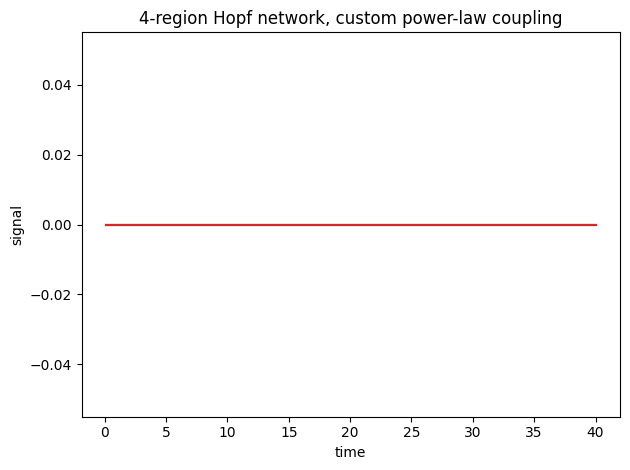

In [5]:
brainmass.viz.plot_timeseries(res['output'], ts=res['ts'])
plt.title('4-region Hopf network, custom power-law coupling')
plt.tight_layout()

## It composes like the built-ins

Because the coupling exposes its parameters as `Param`s, a `Param(..., fit=True)`
makes `k` or `p` a trainable knob the `Fitter` / a hand-written loop can optimise
(see {doc}`building_a_data_driven_workflow`). And because it consumes prefetch
reads rather than raw state, conduction **delays** come for free -- pass a
non-zero `delay_time` matrix and the source read is delayed per connection, no
change to the coupling code.

In [6]:
# Same coupling, now with conduction delays (distance / speed).
dist = np.full((N, N), 10.0)
speed = 10.0                       # mm / ms -> 1 ms delays
delay_time = (dist / speed) * (1.0 - np.eye(N)) * u.ms
node_d = brainmass.HopfStep(N, a=0.2, w=0.3)
net_d = PowerLawNetwork(node_d, conn, coupled_var='x', k=0.5, p=1.5,
                        delay_time=delay_time,
                        delay_init=braintools.init.Uniform(0., 0.05))
res_d = brainmass.Simulator(net_d, dt=0.1 * u.ms).run(
    40. * u.ms, monitors=lambda m: m.node.x.value)
print('delayed run finite:', bool(jnp.isfinite(res_d['output']).all()))

delayed run finite: True


## Checklist for a new coupling

- [ ] a **pure kernel** function: source `(.., N, N)`, target `(.., N)`, conn,
      strength -> current `(.., N)`; strip units before any nonlinearity.
- [ ] a **`Module`** holding `Param.init(...)` parameters and the prefetch reads.
- [ ] `init_state` decorated `@brainstate.nn.call_order(2)` calling
      `init_maybe_prefetch` on each read.
- [ ] `update` reads `.value()` of each `Param` and calls the kernel.
- [ ] (optional) a `@set_module_as('brainmass')` decorator and a `__all__` entry if
      you are contributing it upstream, plus a branch in `Network`'s `coupling=`
      dispatch.

## See Also

- {doc}`/howto/custom_coupling` -- using the built-in couplings via `Network`.
- {doc}`/concepts/coupling_and_delays` -- the theory of coupling and delays.
- {doc}`creating_models` -- the node contract a coupling reads from.